## Computer Vision

### 1. Histogram Low Texture

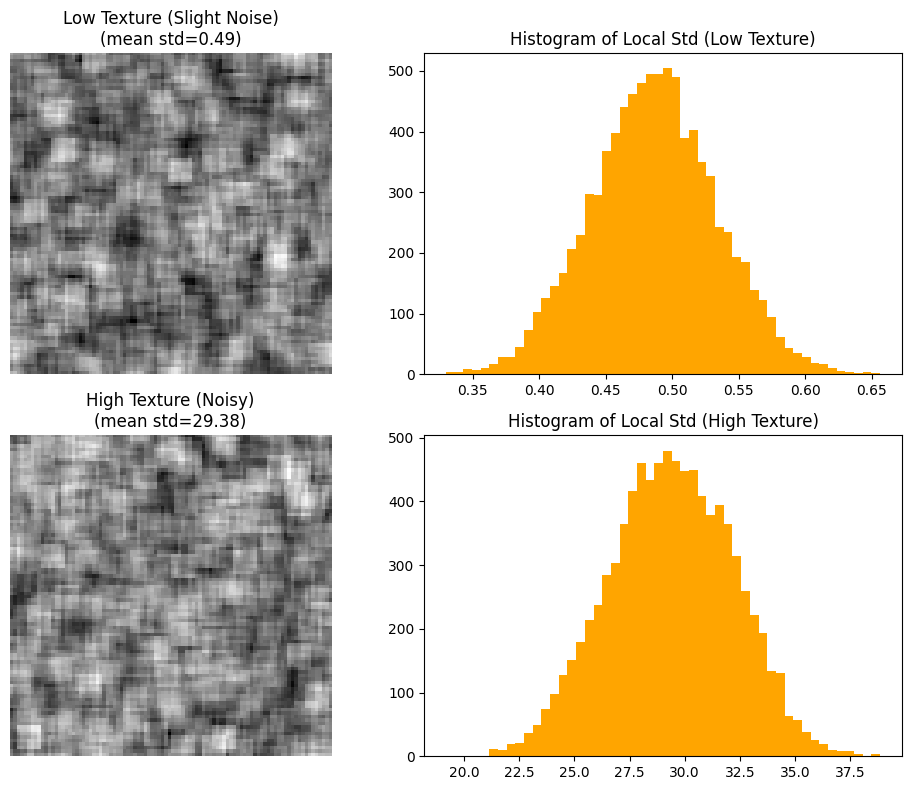

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

# Generate two synthetic images (100x100)
np.random.seed(0)
# Smooth image now with slight noise (low texture but non-zero std)
img_smooth = np.random.normal(loc=128, scale=0.5, size=(100, 100))
# Noisy image (high texture)
img_noisy  = np.random.normal(loc=128, scale=30, size=(100, 100))

# Compute local standard deviation with a 7x7 window
window_size = 7
def local_std(img):
    w = sliding_window_view(img, (window_size, window_size))
    return w.std(axis=(2, 3))

std_smooth = local_std(img_smooth)
std_noisy  = local_std(img_noisy)

# Mean std for titles
mean_s = std_smooth.mean()
mean_n = std_noisy.mean()

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Smooth local std map and histogram
axes[0, 0].imshow(std_smooth, cmap='gray')
axes[0, 0].set_title(f"Low Texture (Slight Noise)\n(mean std={mean_s:.2f})")
axes[0, 0].axis('off')

axes[0, 1].hist(std_smooth.flatten(), bins=50, color='orange')
axes[0, 1].set_title("Histogram of Local Std (Low Texture)")

# Noisy local std map and histogram
axes[1, 0].imshow(std_noisy, cmap='gray')
axes[1, 0].set_title(f"High Texture (Noisy)\n(mean std={mean_n:.2f})")
axes[1, 0].axis('off')

axes[1, 1].hist(std_noisy.flatten(), bins=50, color='orange')
axes[1, 1].set_title("Histogram of Local Std (High Texture)")

plt.tight_layout()
plt.show()


### 2. Histogram skewness

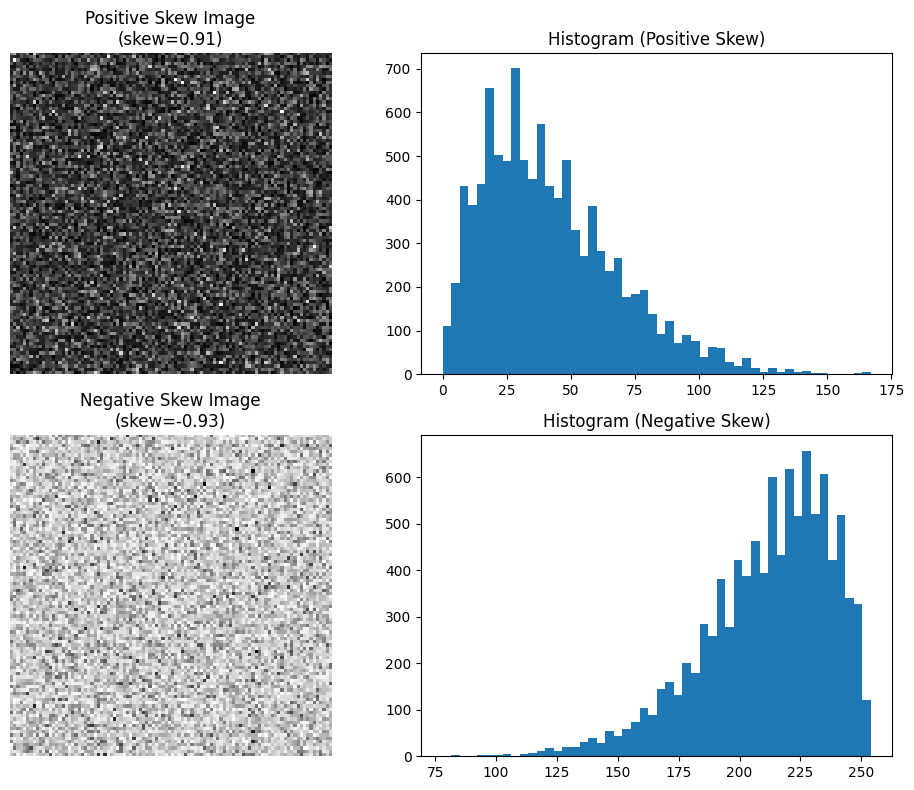

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# Generate two synthetic images (100x100)
# Positive skew: many dark pixels, few bright
np.random.seed(0)
image_pos = (np.random.beta(a=2, b=10, size=(100, 100)) * 255).astype(int)

# Negative skew: many bright pixels, few dark
image_neg = (np.random.beta(a=10, b=2, size=(100, 100)) * 255).astype(int)

# Compute skewness
skew_pos = skew(image_pos.flatten())
skew_neg = skew(image_neg.flatten())

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Positive skew image and histogram
axes[0, 0].imshow(image_pos, cmap='gray')
axes[0, 0].set_title(f"Positive Skew Image\n(skew={skew_pos:.2f})")
axes[0, 0].axis('off')

axes[0, 1].hist(image_pos.flatten(), bins=50)
axes[0, 1].set_title("Histogram (Positive Skew)")

# Negative skew image and histogram
axes[1, 0].imshow(image_neg, cmap='gray')
axes[1, 0].set_title(f"Negative Skew Image\n(skew={skew_neg:.2f})")
axes[1, 0].axis('off')

axes[1, 1].hist(image_neg.flatten(), bins=50)
axes[1, 1].set_title("Histogram (Negative Skew)")

plt.tight_layout()
plt.show()


### 3. Histogram Kurtosis

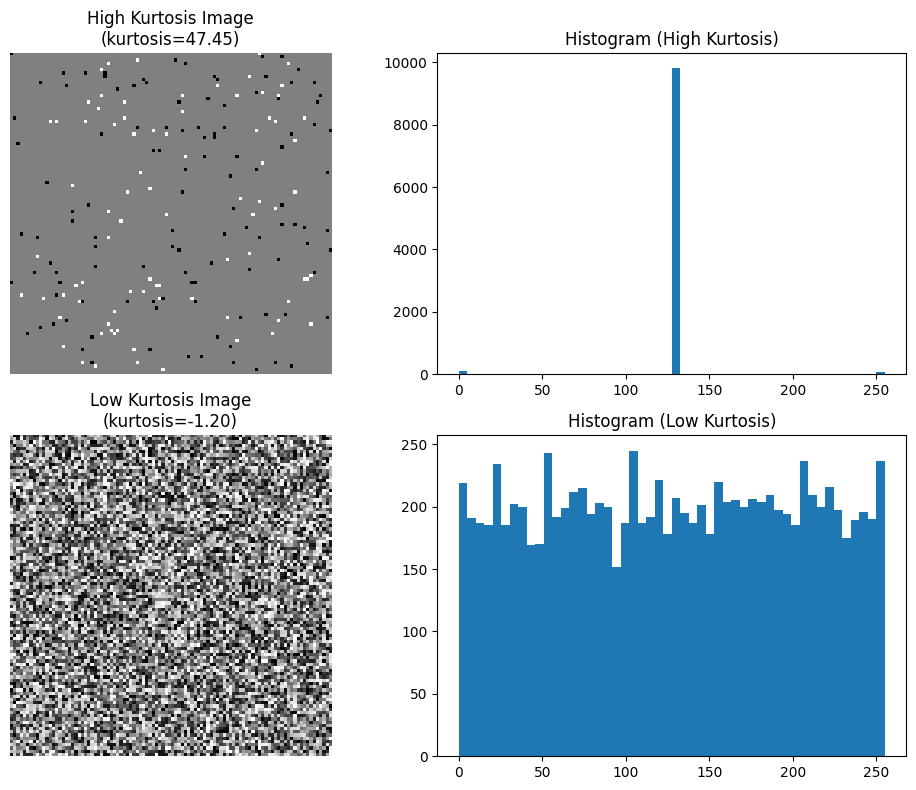

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# Generate two synthetic images (100x100)
np.random.seed(1)

# High kurtosis: mostly constant with few extreme spots
base = np.full((100, 100), 128, dtype=int)
num_spots = 200
coords = (np.random.randint(0, 100, num_spots), np.random.randint(0, 100, num_spots))
base[coords] = np.random.choice([0, 255], size=num_spots)

# Low kurtosis: uniform distribution across range
uniform_img = np.random.randint(0, 256, (100, 100))

# Compute kurtosis
kurt_high = kurtosis(base.flatten(), fisher=True)
kurt_low = kurtosis(uniform_img.flatten(), fisher=True)

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# High kurtosis image and histogram
axes[0, 0].imshow(base, cmap='gray')
axes[0, 0].set_title(f"High Kurtosis Image\n(kurtosis={kurt_high:.2f})")
axes[0, 0].axis('off')

axes[0, 1].hist(base.flatten(), bins=50)
axes[0, 1].set_title("Histogram (High Kurtosis)")

# Low kurtosis image and histogram
axes[1, 0].imshow(uniform_img, cmap='gray')
axes[1, 0].set_title(f"Low Kurtosis Image\n(kurtosis={kurt_low:.2f})")
axes[1, 0].axis('off')

axes[1, 1].hist(uniform_img.flatten(), bins=50)
axes[1, 1].set_title("Histogram (Low Kurtosis)")

plt.tight_layout()
plt.show()

### 4. GLCM

In [ ]:
!pip install scikit-image

In [ ]:
import skimage
print(skimage.__version__)
from skimage.feature import graycomatrix, graycoprops
print("scikit-image and its modules are successfully imported!")

0.25.2
scikit-image and its modules are successfully imported!


In [ ]:
# Contoh matrix 8-bit (0–255), ukuran kecil untuk ilustrasi
image = np.array([
    [  0,   0,  10,  10],
    [  0,   0,  10,  10],
    [100, 100, 200, 200],
    [100, 100, 200, 200]
], dtype=np.uint8)

# Hitung GLCM pada jarak 1 dan arah 0° (horizontal)
glcm = graycomatrix(image,
                    distances=[1],
                    angles=[0],
                    levels=256,
                    symmetric=True,
                    normed=True)

# Ekstrak beberapa Haralick features
contrast       = graycoprops(glcm, 'contrast')[0, 0]
homogeneity    = graycoprops(glcm, 'homogeneity')[0, 0]
energy         = graycoprops(glcm, 'energy')[0, 0]
correlation    = graycoprops(glcm, 'correlation')[0, 0]
dissimilarity  = graycoprops(glcm, 'dissimilarity')[0, 0]

print(f"Contrast:      {contrast:.4f}")
print(f"Homogeneity:   {homogeneity:.4f}")
print(f"Energy:        {energy:.4f}")
print(f"Correlation:   {correlation:.4f}")
print(f"Dissimilarity: {dissimilarity:.4f}")


Contrast:      1683.3333
Homogeneity:   0.6683
Energy:        0.3727
Correlation:   0.8709
Dissimilarity: 18.3333


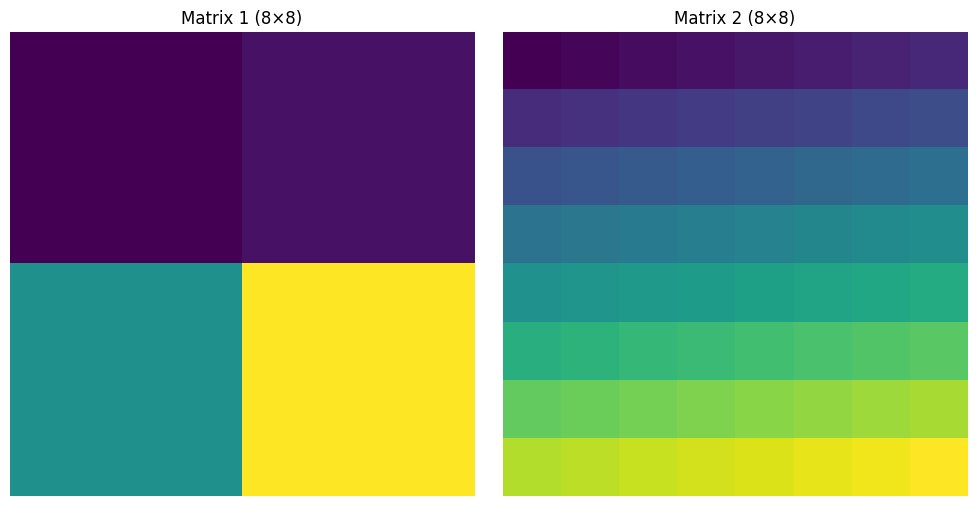

Feature            Matrix1    Matrix2
-------------------------------------
contrast          721.4286    16.4821
homogeneity         0.8579     0.0577
energy              0.4345     0.0945
correlation         0.9447     0.9985
dissimilarity       7.8571     4.0536


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

# Define larger (8x8) example matrices
matrix1 = np.array([
    [0, 0, 0, 0, 10, 10, 10, 10],
    [0, 0, 0, 0, 10, 10, 10, 10],
    [0, 0, 0, 0, 10, 10, 10, 10],
    [0, 0, 0, 0, 10, 10, 10, 10],
    [100, 100, 100, 100, 200, 200, 200, 200],
    [100, 100, 100, 100, 200, 200, 200, 200],
    [100, 100, 100, 100, 200, 200, 200, 200],
    [100, 100, 100, 100, 200, 200, 200, 200]
], dtype=np.uint8)

matrix2 = np.linspace(0, 255, 64, dtype=np.uint8).reshape((8, 8))

# Compute Haralick features
def compute_haralick(mat, distances=[1], angles=[0]):
    glcm = graycomatrix(mat, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    return {
        'contrast': graycoprops(glcm, 'contrast')[0,0],
        'homogeneity': graycoprops(glcm, 'homogeneity')[0,0],
        'energy': graycoprops(glcm, 'energy')[0,0],
        'correlation': graycoprops(glcm, 'correlation')[0,0],
        'dissimilarity': graycoprops(glcm, 'dissimilarity')[0,0]
    }

feat1 = compute_haralick(matrix1)
feat2 = compute_haralick(matrix2)

# Plot heatmaps
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(matrix1, interpolation='nearest')
axs[0].set_title("Matrix 1 (8×8)")
axs[0].axis('off')

axs[1].imshow(matrix2, interpolation='nearest')
axs[1].set_title("Matrix 2 (8×8)")
axs[1].axis('off')

plt.tight_layout()
plt.show()

# Compute features
feat1 = compute_haralick(matrix1)
feat2 = compute_haralick(matrix2)

# Print results in a table format
print(f"{'Feature':<15} {'Matrix1':>10} {'Matrix2':>10}")
print('-' * 37)
for key in feat1:
    print(f"{key:<15} {feat1[key]:>10.4f} {feat2[key]:>10.4f}")